In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import association_rules , apriori
from mlxtend.preprocessing import TransactionEncoder

In [22]:
df = pd.read_csv('../../spreadsheets/chipotle.csv')

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction         4622 non-null   int64  
 1   quantity            4622 non-null   int64  
 2   Item                4622 non-null   str    
 3   choice_description  3376 non-null   str    
 4   item_price          4622 non-null   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 180.7 KB


In [24]:
df.head()

,Transaction,quantity,Item,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,[Clementine],3.39
2,1,1,Nantucket Nectar,[Apple],3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98


In [25]:
len(df['Item'].unique()) # type of food

50

In [26]:
temp = df[df.item_price == df.item_price.max()] # The most expensive food
temp = temp[['Item','item_price']].drop_duplicates()
temp

,Item,item_price
3598,Chips and Fresh Tomato Salsa,44.25


In [27]:
len(df['Transaction'].unique()) 

1834

In [ ]:
sales_quantity = df.groupby('Item').count()
sales_quantity = sales_quantity.sort_values('Transaction', ascending=False)
sales_quantity ['Transaction']

Item
Chicken Bowl                             726
Chicken Burrito                          553
Chips and Guacamole                      479
Steak Burrito                            368
Canned Soft Drink                        301
Chips                                    211
Steak Bowl                               211
Bottled Water                            162
Chicken Soft Tacos                       115
Chicken Salad Bowl                       110
Chips and Fresh Tomato Salsa             110
Canned Soda                              104
Side of Chips                            101
Veggie Burrito                            95
Barbacoa Burrito                          91
Veggie Bowl                               85
Carnitas Bowl                             68
Barbacoa Bowl                             66
Carnitas Burrito                          59
Steak Soft Tacos                          55
6 Pack Soft Drink                         54
Chips and Tomatillo Red Chili Salsa       48
Chick

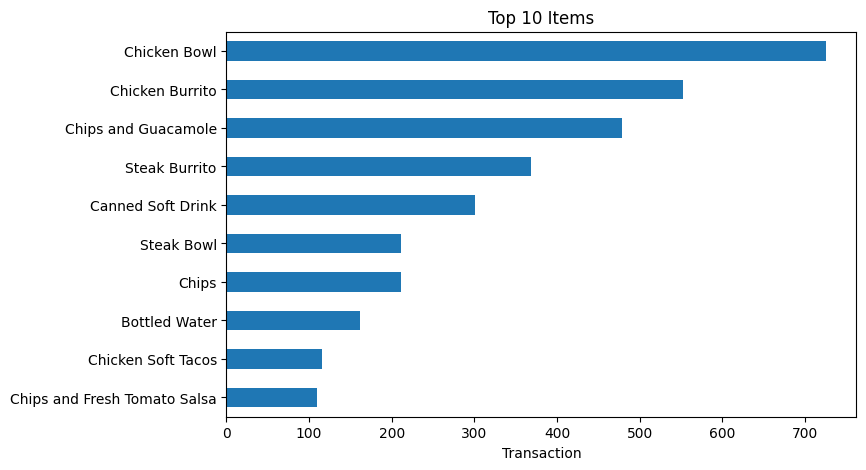

In [ ]:
top_ten = sales_quantity.sort_values('Transaction').tail(10)
top_ten = top_ten ['Transaction']
top_ten.plot.barh(xlabel ='Transaction', # x -axis label
    ylabel ='', # y -axis label
    title='Top 10 Items', # Graph title
    figsize =(9,5))
plt.subplots_adjust(left=0.2) # graph left margin
plt.show()

In [ ]:
temp = df[['Transaction','Item']].drop_duplicates()
temp = temp.groupby('Transaction')['Item'].apply(list)
temp

Transaction
1       [Chips and Fresh Tomato Salsa, Izze, Nantucket...
2                                          [Chicken Bowl]
3                           [Chicken Bowl, Side of Chips]
4                       [Steak Burrito, Steak Soft Tacos]
5                    [Steak Burrito, Chips and Guacamole]
                              ...                        
1830                      [Steak Burrito, Veggie Burrito]
1831                [Carnitas Bowl, Chips, Bottled Water]
1832            [Chicken Soft Tacos, Chips and Guacamole]
1833                                      [Steak Burrito]
1834                                 [Chicken Salad Bowl]
Name: Item, Length: 1834, dtype: object

In [31]:
te = TransactionEncoder()
trans_matrix = te.fit(temp).transform(temp)
trans_matrix

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(1834, 50))

In [34]:
basket = pd.DataFrame(trans_matrix, columns=te.columns_)
basket.head()

,6 Pack Soft Drink,Barbacoa Bowl,Barbacoa Burrito,Barbacoa Crispy Tacos,Barbacoa Salad Bowl,Barbacoa Soft Tacos,Bottled Water,Bowl,Burrito,Canned Soda,...,Steak Crispy Tacos,Steak Salad,Steak Salad Bowl,Steak Soft Tacos,Veggie Bowl,Veggie Burrito,Veggie Crispy Tacos,Veggie Salad,Veggie Salad Bowl,Veggie Soft Tacos
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [35]:
freq_item = apriori(df=basket, min_support = 0.01, use_colnames = True)
freq_item

,support,itemsets
0,0.029444,frozenset({6 Pack Soft Drink})
1,0.033261,frozenset({Barbacoa Bowl})
2,0.047983,frozenset({Barbacoa Burrito})
3,0.013631,frozenset({Barbacoa Soft Tacos})
4,0.083969,frozenset({Bottled Water})
...,...,...
75,0.014722,"frozenset({Veggie Bowl, Chips and Guacamole})"
76,0.016903,"frozenset({Veggie Burrito, Chips and Guacamole})"
77,0.015267,"frozenset({Bottled Water, Chicken Bowl, Chips})"
78,0.019084,"frozenset({Chicken Bowl, Canned Soft Drink, Ch..."


In [ ]:
rules = association_rules(df= freq_item , metric = 'lift', min_threshold = 1,
                          num_itemsets = len (basket))
rules.sort_values('confidence', ascending = False, inplace = True)
rules.head (10)
rules.iloc [0,:].transpose()

antecedents           frozenset({Bottled Water, Chips})
consequents                   frozenset({Chicken Bowl})
antecedent support                             0.019084
consequent support                             0.335333
support                                        0.015267
confidence                                          0.8
lift                                           2.385691
representativity                                    1.0
leverage                                       0.008868
conviction                                     3.323337
zhangs_metric                                  0.592135
jaccard                                        0.045016
certainty                                      0.699098
kulczynski                                     0.422764
Name: 37, dtype: object